# 1. Índice de vulnerabilidad (paramétrico)

Versión paramétrica de `1.vulnerability_index.ipynb`. Misma lógica exacta
(StandardScaler → índice promedio → quintiles y tercios), pero lee/escribe según
`config.py`. El original se conserva intacto para el paper.

**Entrada:** `manzanas_{zona}_paper.parquet` (nb 0.3)

**Salida:** `manzanas_{zona}_sim.parquet` + `.gpkg`

**Nota metodológica:** el índice es relativo a las manzanas de la zona activa
(z-scores y quintiles se calculan sobre el conjunto). Al escalar a más comunas,
la vulnerabilidad queda medida respecto a toda la zona, no solo Peñalolén.

---

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
from config import ZONA, FP_MANZ_PAPER, FP_MANZ_SIM, CRS_PROJ

import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Carga de base procesada de manzanas
manz = gpd.read_parquet(FP_MANZ_PAPER).to_crs(CRS_PROJ)
print(f'Zona: {ZONA} | Dimensión base: {manz.shape}')
manz.head()

Zona: suroriente | Dimensión base: (6782, 22)


,CUT,COMUNA,COD_ZONA,MANZENT,COD_MANZANA,SHAPE,n_per,n_edad_60_mas,prom_edad,prom_escolaridad18,...,pct_dif_mover,pct_analfabet,pct_terciaria,pct_camina,pct_hacinamiento,pct_allegados,pct_precar_pared,pct_precar_techo,pct_piso_tierra,pct_sin_sanit
27049,13110,LA FLORIDA,1,1.311001e+13,3,"MULTIPOLYGON (((350208.005 6291107.202, 350222...",663.0,71.0,33.8,14.5,...,0.015083,0.000000,0.431373,0.034691,0.037707,0.015083,0.0,0.0,0.0,0.0
27050,13110,LA FLORIDA,1,1.311001e+13,5,"MULTIPOLYGON (((350557.608 6290906.737, 350504...",581.0,79.0,36.6,15.4,...,0.018933,0.000000,0.521515,0.032702,0.015491,0.012048,0.0,0.0,0.0,0.0
27051,13110,LA FLORIDA,1,1.311001e+13,6,"MULTIPOLYGON (((350578.032 6290873.973, 350579...",33.0,7.0,37.9,14.0,...,0.060606,0.000000,0.424242,0.030303,0.000000,0.000000,0.0,0.0,0.0,0.0
27052,13110,LA FLORIDA,1,1.311001e+13,7,"MULTIPOLYGON (((350561.109 6290793.953, 350566...",447.0,34.0,31.8,15.3,...,0.015660,0.000000,0.552573,0.031320,0.026846,0.006711,0.0,0.0,0.0,0.0
27053,13110,LA FLORIDA,1,1.311001e+13,11,"MULTIPOLYGON (((350589.679 6290638.856, 350606...",1338.0,121.0,32.4,14.5,...,0.018685,0.001495,0.464873,0.054559,0.051570,0.011211,0.0,0.0,0.0,0.0


In [3]:
# 2. Variables para el índice de vulnerabilidad
vars_vuln = [
    'pct_60mas',
    'pct_discapacidad',
    'pct_analfabet',
    'pct_hacinamiento',
    'pct_allegados',
    'pct_camina',
]
vars_check = vars_vuln + ['pct_terciaria']
manz[vars_check].describe().T

,count,mean,std,min,25%,50%,75%,max
pct_60mas,6782.0,0.252542,0.099818,0.0,0.188976,0.250000,0.311111,1.000000
pct_discapacidad,6782.0,0.100106,0.058371,0.0,0.058068,0.094340,0.134615,0.855769
pct_analfabet,6782.0,0.010982,0.016436,0.0,0.000000,0.001340,0.017699,0.244019
pct_hacinamiento,6782.0,0.014622,0.017269,0.0,0.000000,0.010204,0.024096,0.133333
pct_allegados,6782.0,0.015917,0.023180,0.0,0.000000,0.007937,0.023256,0.388889
pct_camina,6782.0,0.026614,0.027250,0.0,0.000000,0.021277,0.039677,0.300000
pct_terciaria,6782.0,0.320683,0.183990,0.0,0.150000,0.303899,0.481412,0.837607


In [4]:
# 3. Correlaciones entre variables seleccionadas
print(manz[vars_check].corr().round(2))

                  pct_60mas  pct_discapacidad  pct_analfabet  \
pct_60mas              1.00              0.30          -0.01   
pct_discapacidad       0.30              1.00           0.37   
pct_analfabet         -0.01              0.37           1.00   
pct_hacinamiento      -0.18              0.21           0.28   
pct_allegados          0.03              0.22           0.23   
pct_camina            -0.06              0.19           0.21   
pct_terciaria          0.06             -0.50          -0.48   

                  pct_hacinamiento  pct_allegados  pct_camina  pct_terciaria  
pct_60mas                    -0.18           0.03       -0.06           0.06  
pct_discapacidad              0.21           0.22        0.19          -0.50  
pct_analfabet                 0.28           0.23        0.21          -0.48  
pct_hacinamiento              1.00           0.29        0.28          -0.48  
pct_allegados                 0.29           1.00        0.22          -0.32  
pct_camina   

In [5]:
# 4. Construcción del índice — pct_terciaria entra como factor protector (signo -)
X = manz[vars_vuln].copy()
X['inv_pct_terciaria'] = -manz['pct_terciaria']

scaler = StandardScaler()
Xz = scaler.fit_transform(X)
manz['indice_vulnerabilidad'] = Xz.mean(axis=1)

print(manz['indice_vulnerabilidad'].describe())

count    6.782000e+03
mean     2.304916e-17
std      5.754847e-01
min     -1.342787e+00
25%     -4.494486e-01
50%     -4.396404e-02
75%      3.984965e-01
max      3.267285e+00
Name: indice_vulnerabilidad, dtype: float64


In [6]:
# 5. Clasificación ordinal: quintiles (mapas) y 3 grupos (simulación/EOD)
manz['vuln_q'] = pd.qcut(
    manz['indice_vulnerabilidad'], q=5,
    labels=['Muy baja', 'Baja', 'Media', 'Alta', 'Muy alta'])

manz['vuln_group'] = pd.qcut(
    manz['indice_vulnerabilidad'], q=3,
    labels=['baja', 'media', 'alta'])

print(manz['vuln_group'].value_counts())

vuln_group
baja     2261
alta     2261
media    2260
Name: count, dtype: int64


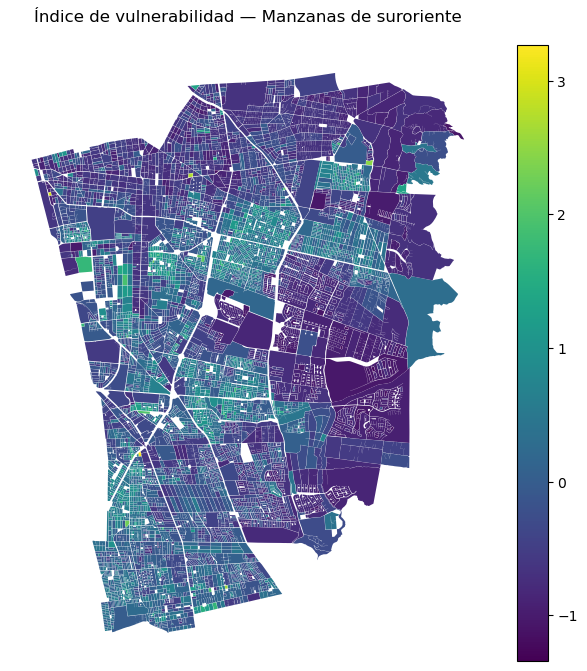

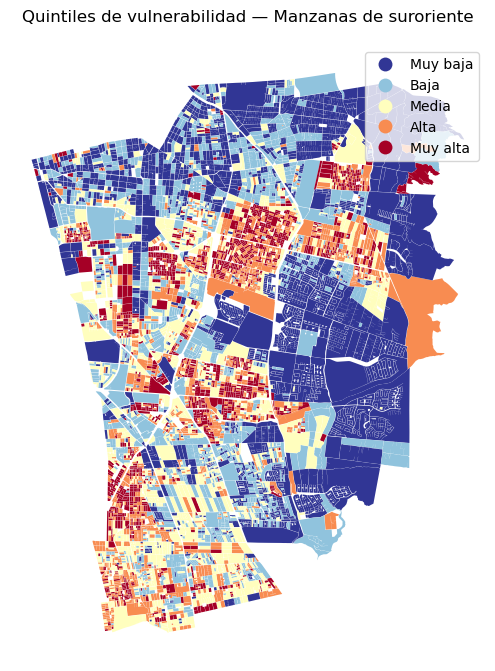

In [7]:
# 6. Mapas de control
ax = manz.plot(column='indice_vulnerabilidad', cmap='viridis', legend=True, figsize=(8, 8))
ax.set_axis_off()
ax.set_title(f'Índice de vulnerabilidad — Manzanas de {ZONA}')
plt.show()

ax = manz.plot(column='vuln_q', cmap='RdYlBu_r', legend=True, figsize=(8, 8))
ax.set_axis_off()
ax.set_title(f'Quintiles de vulnerabilidad — Manzanas de {ZONA}')
plt.show()

In [8]:
# 7. Revisión de extremos
cols_ext = ['MANZENT', 'COD_MANZANA', 'n_per', 'n_edad_60_mas',
            'pct_60mas', 'pct_discapacidad', 'pct_analfabet',
            'pct_hacinamiento', 'pct_allegados', 'pct_camina',
            'pct_terciaria', 'indice_vulnerabilidad', 'vuln_group']
print('Manzanas más vulnerables')
display(manz.sort_values('indice_vulnerabilidad', ascending=False)[cols_ext].head(10))
print('Manzanas menos vulnerables')
display(manz.sort_values('indice_vulnerabilidad', ascending=True)[cols_ext].head(10))

Manzanas más vulnerables


,MANZENT,COD_MANZANA,n_per,n_edad_60_mas,pct_60mas,pct_discapacidad,pct_analfabet,pct_hacinamiento,pct_allegados,pct_camina,pct_terciaria,indice_vulnerabilidad,vuln_group
30582,1.311021e+13,23,20.0,9.0,0.450000,0.300000,0.100000,0.050000,0.000000,0.300000,0.200000,3.267285,alta
54683,1.312010e+13,11,18.0,3.0,0.166667,0.055556,0.000000,0.111111,0.388889,0.055556,0.277778,2.954647,alta
53803,1.312003e+13,26,104.0,104.0,1.000000,0.855769,0.000000,0.000000,0.000000,0.000000,0.000000,2.714308,alta
29132,1.311011e+13,6,37.0,21.0,0.567568,0.270270,0.054054,0.027027,0.162162,0.054054,0.054054,2.596667,alta
33675,1.311307e+13,26,209.0,32.0,0.153110,0.363636,0.244019,0.000000,0.009569,0.047847,0.344498,2.461110,alta
52431,1.311801e+13,20,65.0,21.0,0.323077,0.307692,0.107692,0.030769,0.061538,0.076923,0.092308,2.305558,alta
30099,1.311018e+13,9,148.0,57.0,0.385135,0.412162,0.128378,0.027027,0.033784,0.006757,0.081081,2.268718,alta
31663,1.312204e+13,14,44.0,18.0,0.409091,0.250000,0.136364,0.000000,0.000000,0.136364,0.113636,2.197926,alta
53346,1.311806e+13,27,15.0,5.0,0.333333,0.266667,0.000000,0.066667,0.000000,0.266667,0.200000,2.112589,alta
53191,1.311804e+13,42,48.0,12.0,0.250000,0.291667,0.104167,0.020833,0.104167,0.041667,0.125000,2.101392,alta


Manzanas menos vulnerables


,MANZENT,COD_MANZANA,n_per,n_edad_60_mas,pct_60mas,pct_discapacidad,pct_analfabet,pct_hacinamiento,pct_allegados,pct_camina,pct_terciaria,indice_vulnerabilidad,vuln_group
29940,1.311017e+13,2,28.0,1.0,0.035714,0.0,0.0,0.0,0.0,0.0,0.750000,-1.342787,baja
30847,1.312203e+13,24,38.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.578947,-1.261083,baja
31728,1.312205e+13,30,31.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.548387,-1.237353,baja
31121,1.312203e+13,75,21.0,3.0,0.142857,0.0,0.0,0.0,0.0,0.0,0.809524,-1.235655,baja
31555,1.312203e+13,28,30.0,1.0,0.033333,0.0,0.0,0.0,0.0,0.0,0.600000,-1.229720,baja
31570,1.312203e+13,55,44.0,1.0,0.022727,0.0,0.0,0.0,0.0,0.0,0.568182,-1.220194,baja
33280,1.311305e+13,9,19.0,1.0,0.052632,0.0,0.0,0.0,0.0,0.0,0.578947,-1.185752,baja
31540,1.312203e+13,4,44.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.477273,-1.182133,baja
28159,1.311007e+13,9,53.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.471698,-1.177804,baja
31088,1.312203e+13,50,22.0,1.0,0.045455,0.0,0.0,0.0,0.0,0.0,0.545455,-1.170017,baja


In [9]:
# 8. Geometría operativa para simulación (representative_point cae dentro del polígono)
manz['rep_point'] = manz.geometry.representative_point()
manz['x_rep'] = manz['rep_point'].x
manz['y_rep'] = manz['rep_point'].y
manz['geometry'] = manz['SHAPE']

In [10]:
# 9. Tabla mínima para simulación
cols_sim = ['MANZENT', 'COD_MANZANA', 'n_per', 'n_edad_60_mas',
            'indice_vulnerabilidad', 'vuln_group', 'x_rep', 'y_rep', 'geometry']
manz_sim = manz[cols_sim].copy()
print(f'Dimensión tabla simulación: {manz_sim.shape}')
manz_sim.head()

Dimensión tabla simulación: (6782, 9)


,MANZENT,COD_MANZANA,n_per,n_edad_60_mas,indice_vulnerabilidad,vuln_group,x_rep,y_rep,geometry
27049,1.311001e+13,3,663.0,71.0,-0.310433,baja,350358.289034,6.291021e+06,"MULTIPOLYGON (((350208.005 6291107.202, 350222..."
27050,1.311001e+13,5,581.0,79.0,-0.555326,baja,350458.151846,6.290862e+06,"MULTIPOLYGON (((350557.608 6290906.737, 350504..."
27051,1.311001e+13,6,33.0,7.0,-0.307631,media,350529.543852,6.290858e+06,"MULTIPOLYGON (((350578.032 6290873.973, 350579..."
27052,1.311001e+13,7,447.0,34.0,-0.589080,baja,350566.779616,6.290827e+06,"MULTIPOLYGON (((350561.109 6290793.953, 350566..."
27053,1.311001e+13,11,1338.0,121.0,-0.114753,media,350749.276397,6.290532e+06,"MULTIPOLYGON (((350589.679 6290638.856, 350606..."


In [11]:
# 10. Exportar tabla final del censo para simulación
manz_sim['vuln_group'] = manz_sim['vuln_group'].astype(str)
manz_sim_export = gpd.GeoDataFrame(
    manz_sim.copy(), geometry='geometry', crs=manz_sim['geometry'].crs)

FP_MANZ_SIM.parent.mkdir(parents=True, exist_ok=True)
manz_sim_export.to_parquet(FP_MANZ_SIM)
manz_sim_export.to_file(FP_MANZ_SIM.with_suffix('.gpkg'),
                        layer='manzanas_sim', driver='GPKG')
print(f'Exportado: {FP_MANZ_SIM}')

Exportado: C:\Users\mbell\Desktop\UNIVERSIDAD\DOCTORADO\TESIS\REPOSITORIOS\simulador-am-tesis\data\processed\censo\manzanas_suroriente_sim.parquet
